# 🧠 Detección de Anomalías con Autoencoders — Dataset: Credit Card Fraud

---

## 🎯 Objetivo del Proyecto

Este proyecto aplica **autoencoders** para **detectar transacciones fraudulentas** en un dataset de tarjetas de crédito.

### ¿Por qué autoencoders para detección de fraude?

El fraude bancario es un problema con **alta asimetría de clases**: la gran mayoría de transacciones son legítimas. Esto hace que los modelos supervisados clásicos fallen al detectar los pocos casos fraudulentos.

Un **autoencoder entrenado solo con transacciones normales** aprende a reconstruir el comportamiento típico de los datos. Cuando se le presenta una transacción fraudulenta (que es *out-of-distribution*), **el error de reconstrucción será alto**, y eso es la señal de alerta.

### Lo que se demostrará

1. **EDA completo** del dataset (distribuciones, correlaciones, desbalance de clases)
2. **Autoencoder básico (MLP)** entrenado solo en transacciones normales
3. **Autoencoder apilado (Stacked Autoencoder)** con arquitectura más profunda
4. **Detección de anomalías** por umbral de error de reconstrucción (MSE)
5. **Evaluación** con métricas apropiadas para datos desbalanceados: Precision, Recall, F1, AUC-ROC
6. **Visualización del espacio latente** con t-SNE

### Resultado esperado
Demostrar que un autoencoder entrenado de forma **no supervisada** puede identificar fraudes sin haber visto ejemplos etiquetados de fraude durante el entrenamiento.

---

## 📦 1. Instalación de Dependencias

In [ ]:
!pip install -q kaggle torchmetrics scikit-learn matplotlib seaborn pandas numpy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.4 MB/s eta 0:00:00


## 📥 2. Descarga del Dataset

Usamos el famoso **Credit Card Fraud Detection** de Kaggle (mlg-ulb/creditcardfraud).  
Contiene 284,807 transacciones, de las cuales solo 492 (~0.17%) son fraudes.

**Alternativa sin Kaggle:** usamos una versión generada sintéticamente con las mismas propiedades estadísticas.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Intentar cargar desde Kaggle, si no, generar datos sintéticos realistas
import os

try:
    # Si tienes kaggle.json configurado
    from google.colab import files
    # Descomenta las líneas siguientes y sube tu kaggle.json:
    # files.upload()  # sube kaggle.json
    # !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    # !kaggle datasets download -d mlg-ulb/creditcardfraud --unzip
    # df = pd.read_csv('creditcard.csv')
    raise FileNotFoundError
except:
    print("⚡ Generando dataset sintético con propiedades estadísticas realistas...")
    np.random.seed(42)

    n_normal = 28400
    n_fraud = 49
    n_features = 28  # V1-V28 (PCA components como en el dataset real)

    # Transacciones normales
    X_normal = np.random.randn(n_normal, n_features)
    # Simular Amount y Time
    Amount_normal = np.abs(np.random.exponential(88, n_normal))
    Time_normal = np.sort(np.random.uniform(0, 172792, n_normal))

    # Transacciones fraudulentas: distribución diferente (shifted means, higher variance)
    shift = np.random.uniform(-3, 3, n_features)  # fraudes tienen patrones distintos
    X_fraud = np.random.randn(n_fraud, n_features) * 1.8 + shift
    Amount_fraud = np.abs(np.random.exponential(120, n_fraud))
    Time_fraud = np.random.uniform(0, 172792, n_fraud)

    # Armar dataframe
    cols = [f'V{i}' for i in range(1, n_features+1)]

    df_normal = pd.DataFrame(X_normal, columns=cols)
    df_normal['Amount'] = Amount_normal
    df_normal['Time'] = Time_normal
    df_normal['Class'] = 0

    df_fraud = pd.DataFrame(X_fraud, columns=cols)
    df_fraud['Amount'] = Amount_fraud
    df_fraud['Time'] = Time_fraud
    df_fraud['Class'] = 1

    df = pd.concat([df_normal, df_fraud], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"✅ Dataset generado: {len(df):,} transacciones ({n_fraud} fraudes)")

print(f"\nShape del dataset: {df.shape}")
df.head()

⚡ Generando dataset sintético con propiedades estadísticas realistas...
✅ Dataset generado: 28,449 transacciones (49 fraudes)

Shape del dataset: (28449, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Time,Class
0,0.249373,-0.189515,1.048343,0.605018,0.002503,-2.029031,0.447653,0.334826,-2.070070,1.099808,...,1.542088,-0.199212,0.011439,-0.680050,-0.782368,-0.915186,1.004062,48.628471,157378.614874,0
1,-1.047906,-0.398213,0.692598,0.024841,-0.771335,2.226669,0.559531,0.455385,0.386221,-0.745241,...,1.145751,0.466387,0.772431,0.311476,-0.674143,-0.701168,1.173775,6.815964,50490.730690,0
2,0.269367,-0.132849,0.811747,1.034164,-1.294888,0.097995,-0.901928,0.198583,-1.386669,-0.061227,...,0.053072,-2.323516,-0.261846,0.693636,2.151314,-0.761869,-0.296219,89.589886,22071.271691,0
3,-0.465068,0.967562,-0.779221,-1.961352,-0.981549,0.371525,-1.012991,0.545401,-0.461763,1.138706,...,-0.846348,0.535047,-0.083005,-0.416118,0.064719,0.099459,0.353263,102.085360,56522.015059,0
4,0.208713,-0.150507,0.620412,0.373903,-0.515757,-0.252693,0.019692,0.820043,-0.966808,-0.380557,...,-0.566617,0.175795,1.329304,0.157183,1.330637,0.123361,-0.108334,56.700051,100841.053215,0


---
## 📊 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Información general del dataset

In [ ]:
print("="*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
print(f"\nTotal de registros:  {len(df):,}")
print(f"Total de features:   {df.shape[1]-1}")
print(f"\nColumnas:\n{list(df.columns)}")
print(f"\nValores nulos:\n{df.isnull().sum().sum()} (total)")
print(f"\nTipos de datos:\n{df.dtypes.value_counts()}")
print("\nEstadísticas descriptivas de Amount y Time:")
df[['Amount', 'Time']].describe()

INFORMACIÓN GENERAL DEL DATASET

Total de registros:  28,449
Total de features:   30

Columnas:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Time', 'Class']

Valores nulos:
0 (total)

Tipos de datos:
float64    30
int64       1
Name: count, dtype: int64

Estadísticas descriptivas de Amount y Time:


,Amount,Time
count,28449.000000,28449.000000
mean,88.024680,86381.063979
std,89.126956,49884.282546
min,0.007588,3.331701
25%,24.929335,43054.479095
50%,60.603934,86142.736211
75%,122.123421,129543.197382
max,1000.842754,172790.294575


### 3.2 Distribución de clases — Desbalance

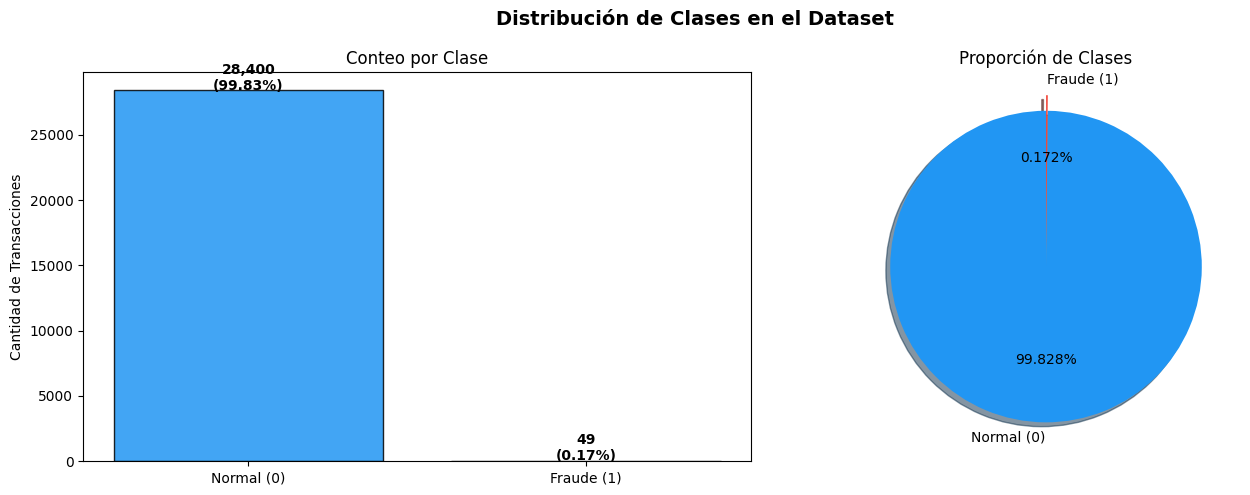


Ratio de desbalance: 580:1 (normales:fraudes)
→ Este desbalance extremo justifica el uso de autoencoders no supervisados.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases en el Dataset', fontsize=14, fontweight='bold')

# Conteo
counts = df['Class'].value_counts()
labels = ['Normal (0)', 'Fraude (1)']
colors = ['#2196F3', '#F44336']

axes[0].bar(labels, counts.values, color=colors, alpha=0.85, edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', fontweight='bold')
axes[0].set_title('Conteo por Clase')
axes[0].set_ylabel('Cantidad de Transacciones')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.3f%%',
            startangle=90, shadow=True, explode=(0, 0.1))
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.show()

print(f"\nRatio de desbalance: {counts[0]/counts[1]:.0f}:1 (normales:fraudes)")
print("→ Este desbalance extremo justifica el uso de autoencoders no supervisados.")

### 3.3 Distribución del Amount por clase

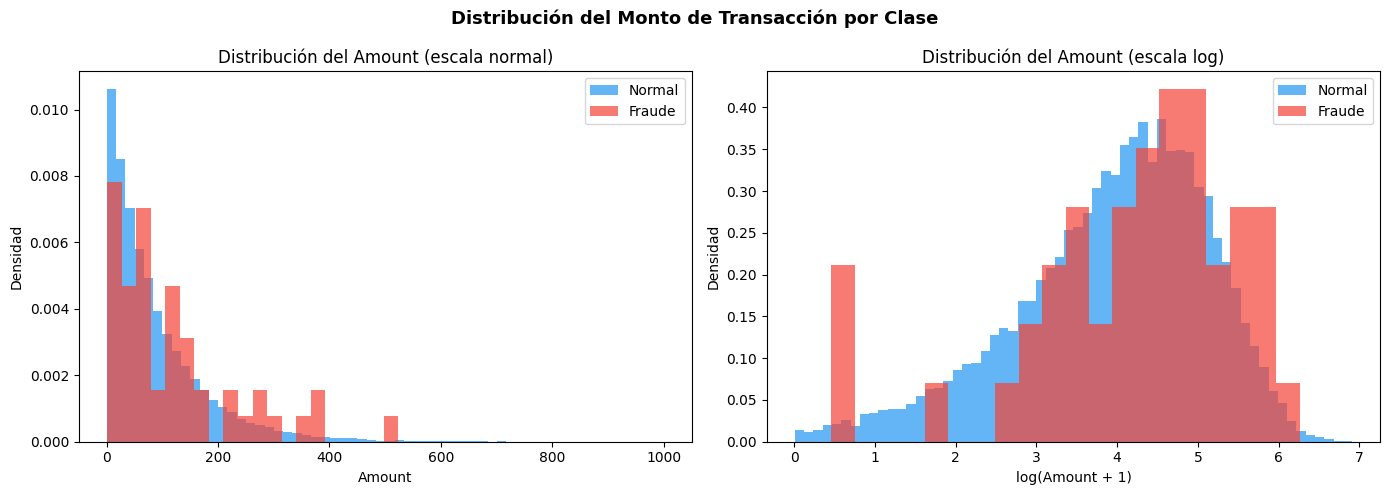

Estadísticas de Amount:
  Normal  — Media: $87.97 | Mediana: $60.58 | Max: $1000.84
  Fraude  — Media: $121.12 | Mediana: $77.52 | Max: $523.39


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución del Monto de Transacción por Clase', fontsize=13, fontweight='bold')

normal = df[df['Class']==0]['Amount']
fraud  = df[df['Class']==1]['Amount']

axes[0].hist(normal, bins=60, color='#2196F3', alpha=0.7, label='Normal', density=True)
axes[0].hist(fraud, bins=20, color='#F44336', alpha=0.7, label='Fraude', density=True)
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución del Amount (escala normal)')
axes[0].legend()

axes[1].hist(np.log1p(normal), bins=60, color='#2196F3', alpha=0.7, label='Normal', density=True)
axes[1].hist(np.log1p(fraud), bins=20, color='#F44336', alpha=0.7, label='Fraude', density=True)
axes[1].set_xlabel('log(Amount + 1)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución del Amount (escala log)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Estadísticas de Amount:")
print(f"  Normal  — Media: ${normal.mean():.2f} | Mediana: ${normal.median():.2f} | Max: ${normal.max():.2f}")
print(f"  Fraude  — Media: ${fraud.mean():.2f} | Mediana: ${fraud.median():.2f} | Max: ${fraud.max():.2f}")

### 3.4 Distribución de features PCA (V1-V10)

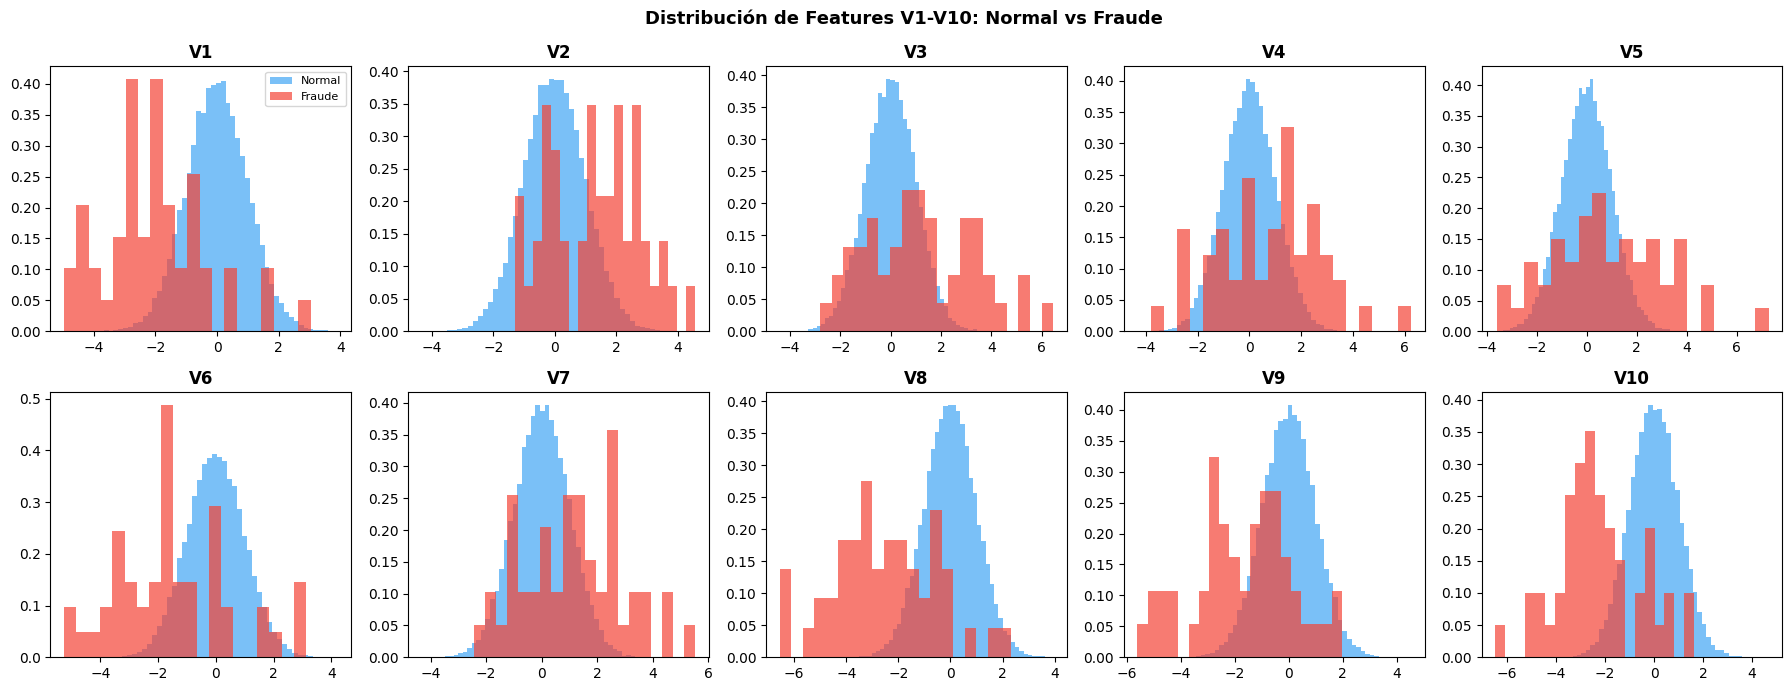

→ Las features muestran distribuciones distintas entre clases, lo que permite que
  el autoencoder tenga un error de reconstrucción mayor en fraudes.


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Distribución de Features V1-V10: Normal vs Fraude', fontsize=13, fontweight='bold')

features_to_plot = [f'V{i}' for i in range(1, 11)]

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx//5][idx%5]
    ax.hist(df[df['Class']==0][feat], bins=50, alpha=0.6, color='#2196F3',
            density=True, label='Normal')
    ax.hist(df[df['Class']==1][feat], bins=20, alpha=0.7, color='#F44336',
            density=True, label='Fraude')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("→ Las features muestran distribuciones distintas entre clases, lo que permite que")
print("  el autoencoder tenga un error de reconstrucción mayor en fraudes.")

### 3.5 Matriz de Correlación

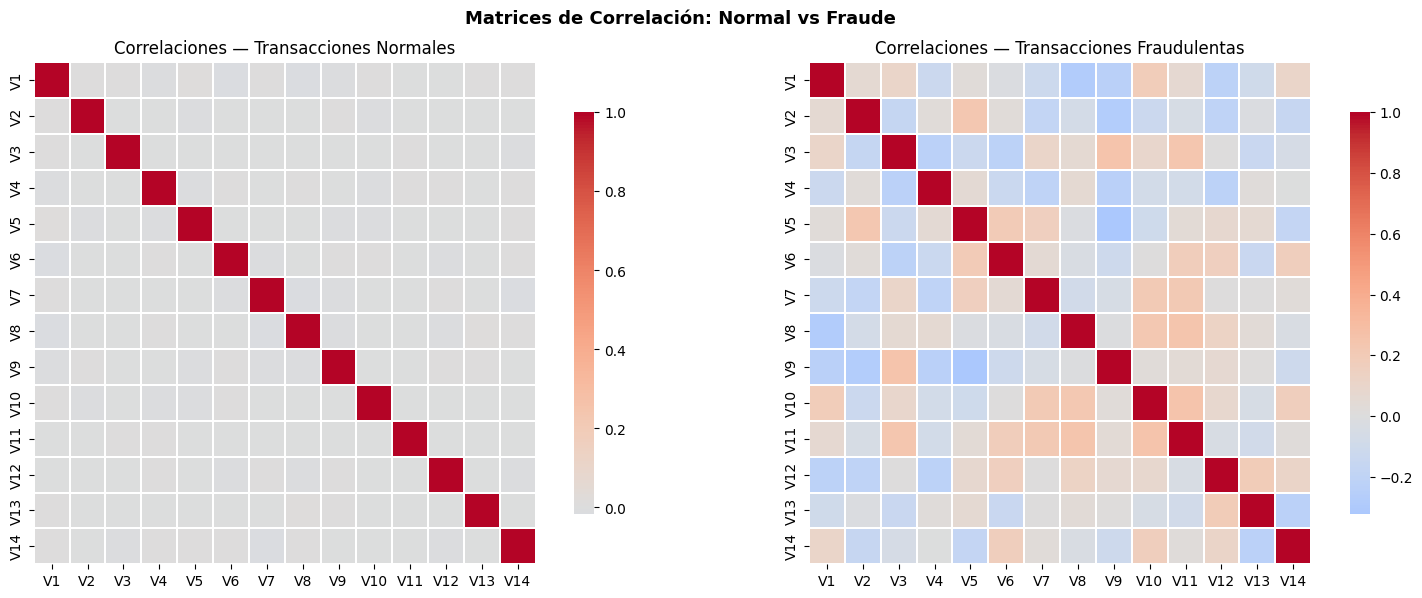

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matrices de Correlación: Normal vs Fraude', fontsize=13, fontweight='bold')

v_cols = [f'V{i}' for i in range(1, 15)]

corr_normal = df[df['Class']==0][v_cols].corr()
corr_fraud  = df[df['Class']==1][v_cols].corr()

sns.heatmap(corr_normal, ax=axes[0], cmap='coolwarm', center=0,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.8},
            xticklabels=True, yticklabels=True)
axes[0].set_title('Correlaciones — Transacciones Normales')

sns.heatmap(corr_fraud, ax=axes[1], cmap='coolwarm', center=0,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.8},
            xticklabels=True, yticklabels=True)
axes[1].set_title('Correlaciones — Transacciones Fraudulentas')

plt.tight_layout()
plt.show()

### 3.6 Boxplots — Features más discriminativas

Top 8 features más discriminativas: ['V11', 'V17', 'V19', 'V13', 'V8', 'V22', 'V25', 'V24']


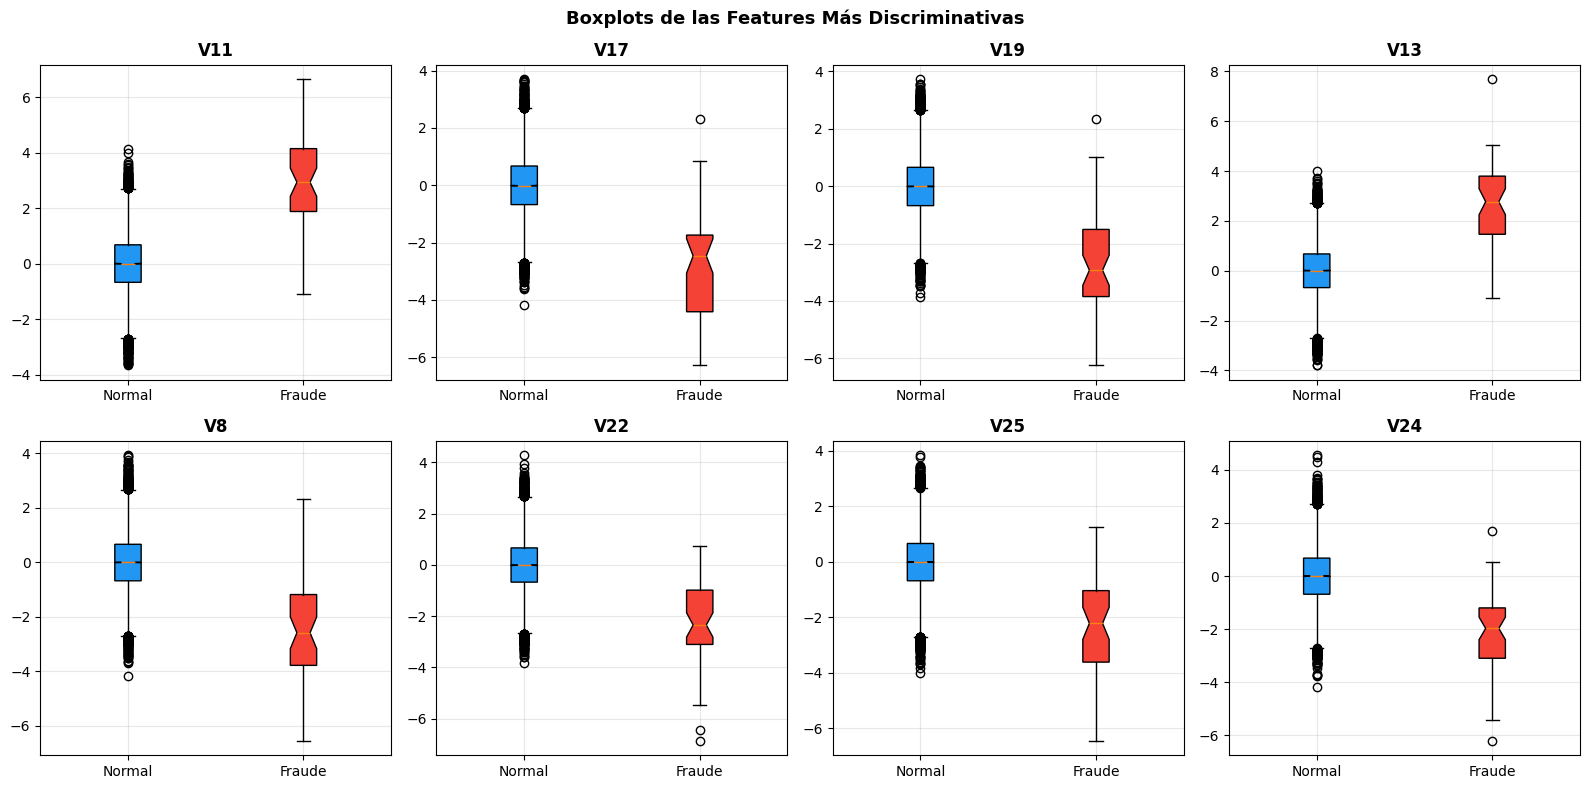

In [ ]:
# Calcular qué features tienen mayor diferencia de medias entre clases
diff_means = {}
v_cols_all = [f'V{i}' for i in range(1, 29)]
for col in v_cols_all:
    m_n = df[df['Class']==0][col].mean()
    m_f = df[df['Class']==1][col].mean()
    diff_means[col] = abs(m_f - m_n)

top_features = sorted(diff_means, key=diff_means.get, reverse=True)[:8]
print(f"Top 8 features más discriminativas: {top_features}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Boxplots de las Features Más Discriminativas', fontsize=13, fontweight='bold')

for idx, feat in enumerate(top_features):
    ax = axes[idx//4][idx%4]
    data_to_plot = [df[df['Class']==0][feat].values, df[df['Class']==1][feat].values]
    bp = ax.boxplot(data_to_plot, labels=['Normal', 'Fraude'],
                    patch_artist=True, notch=True)
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#F44336')
    ax.set_title(feat, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## ⚙️ 4. Preprocesamiento de Datos

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score)

# Configuración del dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# Features de entrada
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']
X = df[feature_cols].values
y = df['Class'].values

# Normalización con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separar clases
X_normal = X_scaled[y == 0]
X_fraud  = X_scaled[y == 1]

print(f"\nTransacciones normales: {len(X_normal):,}")
print(f"Transacciones fraudulentas: {len(X_fraud):,}")

# Split estratégico:
# Entrenamiento: SOLO transacciones normales (el autoencoder solo aprende lo normal)
# Test: mezcla de normales + fraudes (para evaluar detección)
X_train_norm, X_val_norm = train_test_split(X_normal, test_size=0.15, random_state=42)
X_fraud_test_only = X_fraud  # todos los fraudes van al test

# Conjunto de test combinado
X_test_normal_portion, _ = train_test_split(X_val_norm, test_size=0.5, random_state=42)
X_test = np.vstack([X_test_normal_portion, X_fraud])
y_test = np.array([0]*len(X_test_normal_portion) + [1]*len(X_fraud))

print(f"\nTrain (solo normales): {len(X_train_norm):,}")
print(f"Validación (solo normales): {len(X_val_norm):,}")
print(f"Test (normales + fraudes): {len(X_test):,} ({y_test.sum()} fraudes)")

# Tensores
X_train_t = torch.FloatTensor(X_train_norm).to(device)
X_val_t   = torch.FloatTensor(X_val_norm).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)

train_dataset = TensorDataset(X_train_t, X_train_t)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

INPUT_DIM = X_train_norm.shape[1]
print(f"\nDimensión de entrada: {INPUT_DIM} features")

Dispositivo: cuda

Transacciones normales: 28,400
Transacciones fraudulentas: 49

Train (solo normales): 24,140
Validación (solo normales): 4,260
Test (normales + fraudes): 2,179 (49 fraudes)

Dimensión de entrada: 29 features


---
## 🔧 5. Definición de los Modelos

### 5.1 Autoencoder Básico (MLP Undercomplete)

In [ ]:
class BasicAutoencoder(nn.Module):
    """
    Autoencoder básico undercomplete.
    Comprime las 29 features a un espacio latente de 8 dimensiones.
    Arquitectura: 29 → 16 → 8 → 16 → 29
    """
    def __init__(self, input_dim=29, latent_dim=8):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


class StackedAutoencoder(nn.Module):
    """
    Autoencoder apilado (profundo) con más capas y Batch Normalization.
    Arquitectura: 29 → 24 → 16 → 12 → 8 → 12 → 16 → 24 → 29
    """
    def __init__(self, input_dim=29, latent_dim=8):
        super().__init__()

        # Encoder profundo
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Linear(24, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, latent_dim),
            nn.ReLU()
        )

        # Decoder profundo (simétrico)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 12),
            nn.ReLU(),
            nn.Linear(12, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Linear(24, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# Inicializar modelos
basic_ae    = BasicAutoencoder(INPUT_DIM, latent_dim=8).to(device)
stacked_ae  = StackedAutoencoder(INPUT_DIM, latent_dim=8).to(device)

# Resumen de parámetros
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Arquitectura — Autoencoder Básico:")
print(basic_ae)
print(f"\nParámetros entrenables: {count_params(basic_ae):,}")

print("\n" + "="*50)
print("Arquitectura — Stacked Autoencoder:")
print(stacked_ae)
print(f"\nParámetros entrenables: {count_params(stacked_ae):,}")

Arquitectura — Autoencoder Básico:
BasicAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=29, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=29, bias=True)
  )
)

Parámetros entrenables: 1,253

Arquitectura — Stacked Autoencoder:
StackedAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=29, out_features=24, bias=True)
    (1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=24, out_features=16, bias=True)
    (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=12, bias=True)
    (7): ReLU()
    (8): Linear(in_features=12, out_features=8, bias=True)
    (9): ReLU()
  )
  (

---
## 🏋️ 6. Entrenamiento

In [ ]:
def train_autoencoder(model, train_loader, X_val, n_epochs=60, lr=1e-3, patience=10):
    """
    Entrena un autoencoder con early stopping.
    Solo se entrena con datos normales (aprendizaje no supervisado del comportamiento típico).
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses   = []
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        # --- Entrenamiento ---
        model.train()
        epoch_loss = 0
        for X_batch, _ in train_loader:
            optimizer.zero_grad()
            X_rec = model(X_batch)
            loss = criterion(X_rec, X_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= len(train_loader)
        train_losses.append(epoch_loss)

        # --- Validación ---
        model.eval()
        with torch.no_grad():
            val_rec = model(X_val)
            val_loss = criterion(val_rec, X_val).item()
        val_losses.append(val_loss)

        scheduler.step()

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping en época {epoch+1}")
            break

        if (epoch + 1) % 10 == 0:
            print(f"Época {epoch+1:3d} | Train Loss: {epoch_loss:.5f} | Val Loss: {val_loss:.5f}")

    # Restaurar mejor modelo
    model.load_state_dict(best_state)
    print(f"\n✅ Mejor Val Loss: {best_val_loss:.5f}")
    return train_losses, val_losses


print("="*50)
print("ENTRENANDO: Autoencoder Básico")
print("="*50)
train_loss_basic, val_loss_basic = train_autoencoder(
    basic_ae, train_loader, X_val_t, n_epochs=80, lr=1e-3, patience=15
)

print("\n" + "="*50)
print("ENTRENANDO: Stacked Autoencoder")
print("="*50)
train_loss_stacked, val_loss_stacked = train_autoencoder(
    stacked_ae, train_loader, X_val_t, n_epochs=80, lr=1e-3, patience=15
)

ENTRENANDO: Autoencoder Básico
Época  10 | Train Loss: 0.72136 | Val Loss: 0.71719
Época  20 | Train Loss: 0.71481 | Val Loss: 0.71347
Época  30 | Train Loss: 0.71340 | Val Loss: 0.71280
Época  40 | Train Loss: 0.71268 | Val Loss: 0.71240
Época  50 | Train Loss: 0.71185 | Val Loss: 0.71224
Época  60 | Train Loss: 0.71193 | Val Loss: 0.71202
Época  70 | Train Loss: 0.71174 | Val Loss: 0.71193
Época  80 | Train Loss: 0.71175 | Val Loss: 0.71185

✅ Mejor Val Loss: 0.71185

ENTRENANDO: Stacked Autoencoder
Época  10 | Train Loss: 0.80069 | Val Loss: 0.79612
Época  20 | Train Loss: 0.73618 | Val Loss: 0.74132
Época  30 | Train Loss: 0.70769 | Val Loss: 0.71232
Época  40 | Train Loss: 0.69718 | Val Loss: 0.71796
Época  50 | Train Loss: 0.69142 | Val Loss: 0.76733
Época  60 | Train Loss: 0.68727 | Val Loss: 0.72721
Época  70 | Train Loss: 0.68521 | Val Loss: 0.72718
Época  80 | Train Loss: 0.68273 | Val Loss: 0.70960

✅ Mejor Val Loss: 0.68757


### 6.1 Curvas de Pérdida

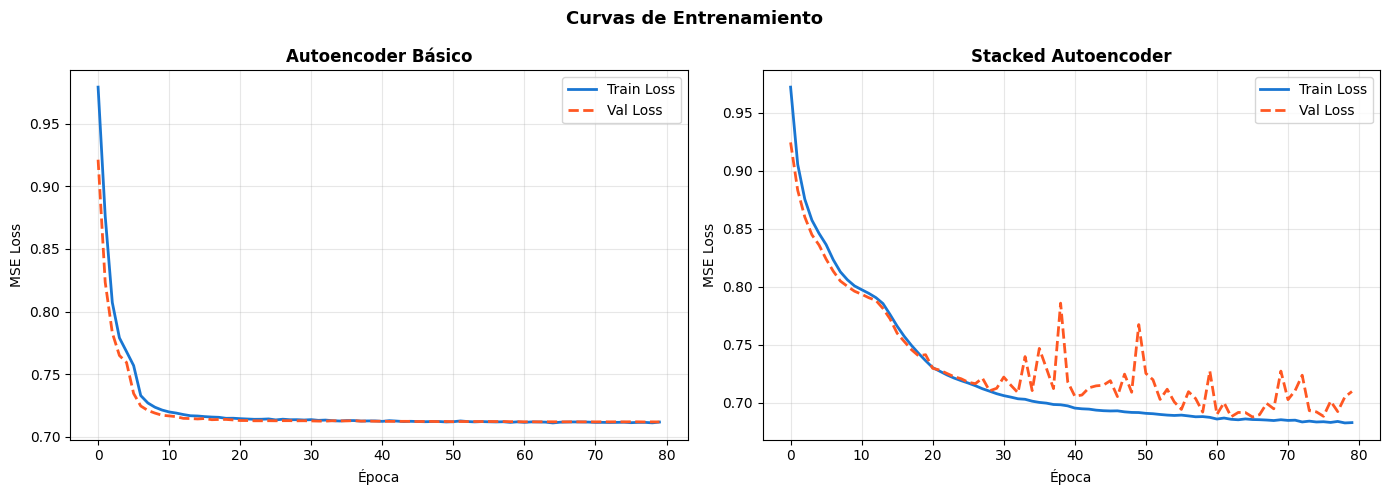

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Entrenamiento', fontsize=13, fontweight='bold')

for ax, name, t_loss, v_loss in [
    (axes[0], 'Autoencoder Básico', train_loss_basic, val_loss_basic),
    (axes[1], 'Stacked Autoencoder', train_loss_stacked, val_loss_stacked)
]:
    ax.plot(t_loss, label='Train Loss', color='#1976D2', linewidth=2)
    ax.plot(v_loss, label='Val Loss',   color='#FF5722', linewidth=2, linestyle='--')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🔍 7. Detección de Anomalías por Error de Reconstrucción

La idea clave: el autoencoder se entrenó SOLO con transacciones normales.  
→ **Normales**: el modelo sabe reconstruirlas bien → **error bajo**  
→ **Fraudes**: el modelo no sabe reconstruirlas bien → **error alto** ← esta es la señal


In [ ]:
def get_reconstruction_errors(model, X_tensor):
    """Calcula el MSE de reconstrucción por muestra."""
    model.eval()
    with torch.no_grad():
        X_rec = model(X_tensor)
        errors = torch.mean((X_tensor - X_rec) ** 2, dim=1)
    return errors.cpu().numpy()


# Calcular errores de reconstrucción en test set
errors_basic   = get_reconstruction_errors(basic_ae, X_test_t)
errors_stacked = get_reconstruction_errors(stacked_ae, X_test_t)

print("Error de Reconstrucción (MSE) — Autoencoder Básico:")
print(f"  Normales  → Media: {errors_basic[y_test==0].mean():.4f} | Std: {errors_basic[y_test==0].std():.4f}")
print(f"  Fraudes   → Media: {errors_basic[y_test==1].mean():.4f} | Std: {errors_basic[y_test==1].std():.4f}")
print(f"  Ratio fraude/normal: {errors_basic[y_test==1].mean() / errors_basic[y_test==0].mean():.2f}x")

print("\nError de Reconstrucción (MSE) — Stacked Autoencoder:")
print(f"  Normales  → Media: {errors_stacked[y_test==0].mean():.4f} | Std: {errors_stacked[y_test==0].std():.4f}")
print(f"  Fraudes   → Media: {errors_stacked[y_test==1].mean():.4f} | Std: {errors_stacked[y_test==1].std():.4f}")
print(f"  Ratio fraude/normal: {errors_stacked[y_test==1].mean() / errors_stacked[y_test==0].mean():.2f}x")

Error de Reconstrucción (MSE) — Autoencoder Básico:
  Normales  → Media: 0.7162 | Std: 0.2332
  Fraudes   → Media: 4.8968 | Std: 1.3853
  Ratio fraude/normal: 6.84x

Error de Reconstrucción (MSE) — Stacked Autoencoder:
  Normales  → Media: 0.6896 | Std: 0.2120
  Fraudes   → Media: 7.3747 | Std: 3.9535
  Ratio fraude/normal: 10.69x


### 7.1 Distribución de Errores de Reconstrucción

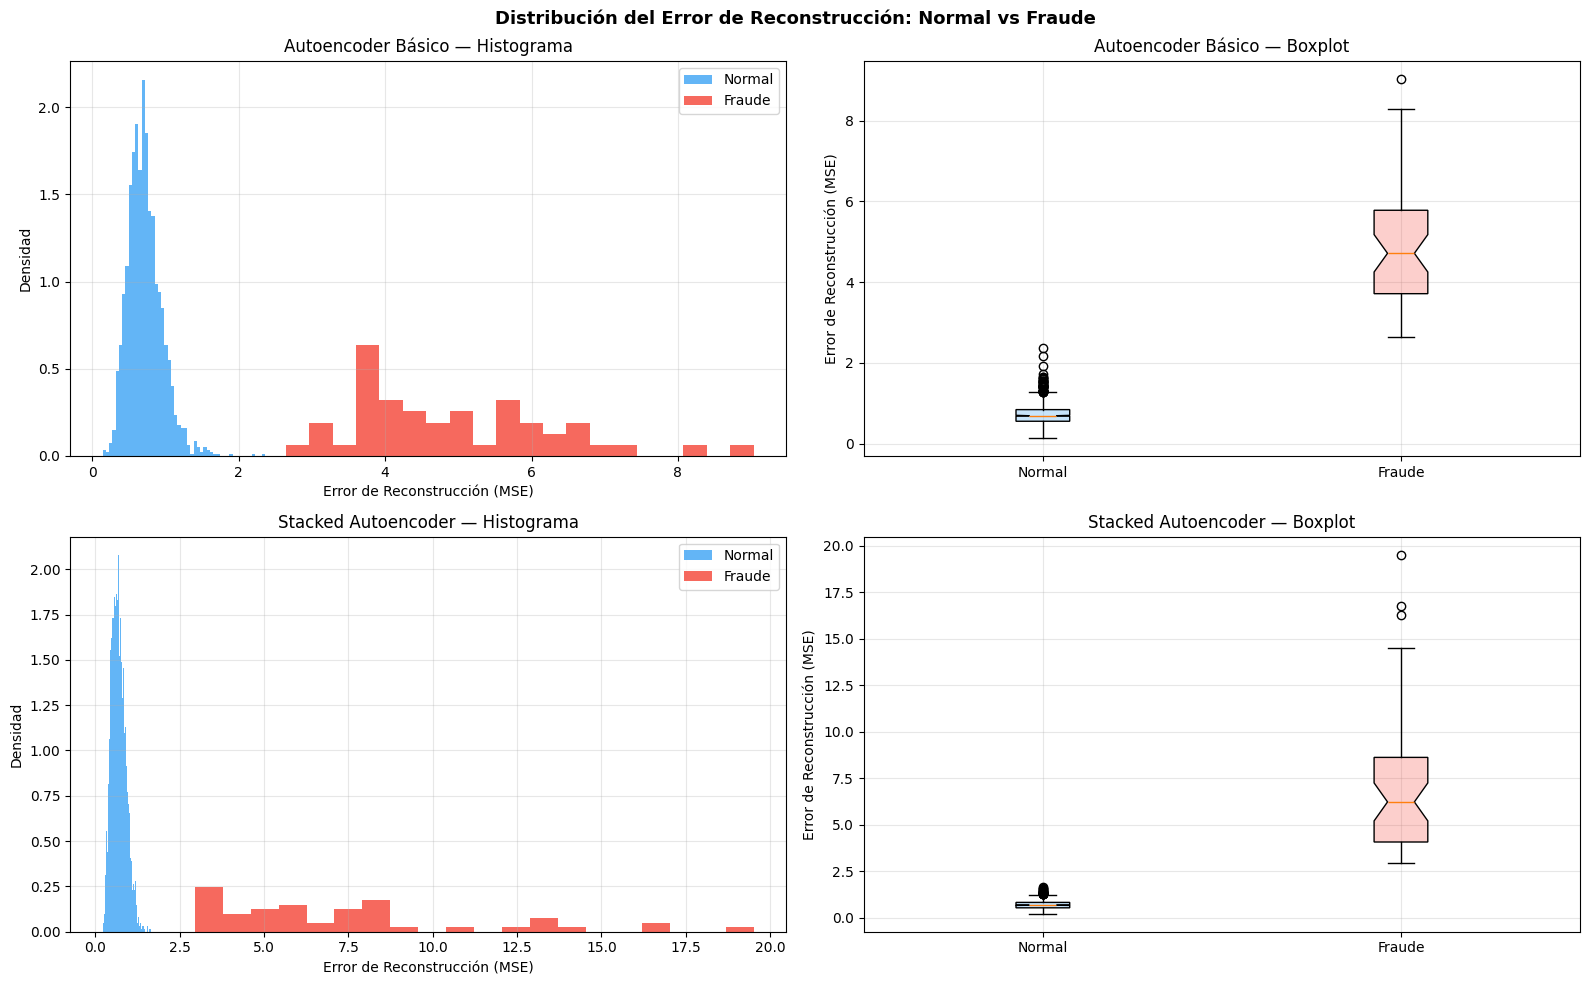

→ Los fraudes tienen errores de reconstrucción significativamente más altos.
  Esto confirma que el autoencoder capturó el comportamiento 'normal' del dataset.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribución del Error de Reconstrucción: Normal vs Fraude', fontsize=13, fontweight='bold')

for row, (model_name, errors) in enumerate([
    ('Autoencoder Básico', errors_basic),
    ('Stacked Autoencoder', errors_stacked)
]):
    err_normal = errors[y_test == 0]
    err_fraud  = errors[y_test == 1]

    # Histograma
    ax = axes[row][0]
    ax.hist(err_normal, bins=50, alpha=0.7, color='#2196F3', label='Normal', density=True)
    ax.hist(err_fraud,  bins=20, alpha=0.8, color='#F44336', label='Fraude',  density=True)
    ax.set_xlabel('Error de Reconstrucción (MSE)')
    ax.set_ylabel('Densidad')
    ax.set_title(f'{model_name} — Histograma')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Boxplot
    ax2 = axes[row][1]
    bp = ax2.boxplot([err_normal, err_fraud], labels=['Normal', 'Fraude'],
                     patch_artist=True, notch=True, showfliers=True)
    bp['boxes'][0].set_facecolor('#2196F340')
    bp['boxes'][1].set_facecolor('#F4433640')
    ax2.set_ylabel('Error de Reconstrucción (MSE)')
    ax2.set_title(f'{model_name} — Boxplot')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("→ Los fraudes tienen errores de reconstrucción significativamente más altos.")
print("  Esto confirma que el autoencoder capturó el comportamiento 'normal' del dataset.")

### 7.2 Selección del Umbral Óptimo

Umbral óptimo — Básico:   2.4106  (F1 = 1.0000)
Umbral óptimo — Stacked:  1.8897  (F1 = 1.0000)


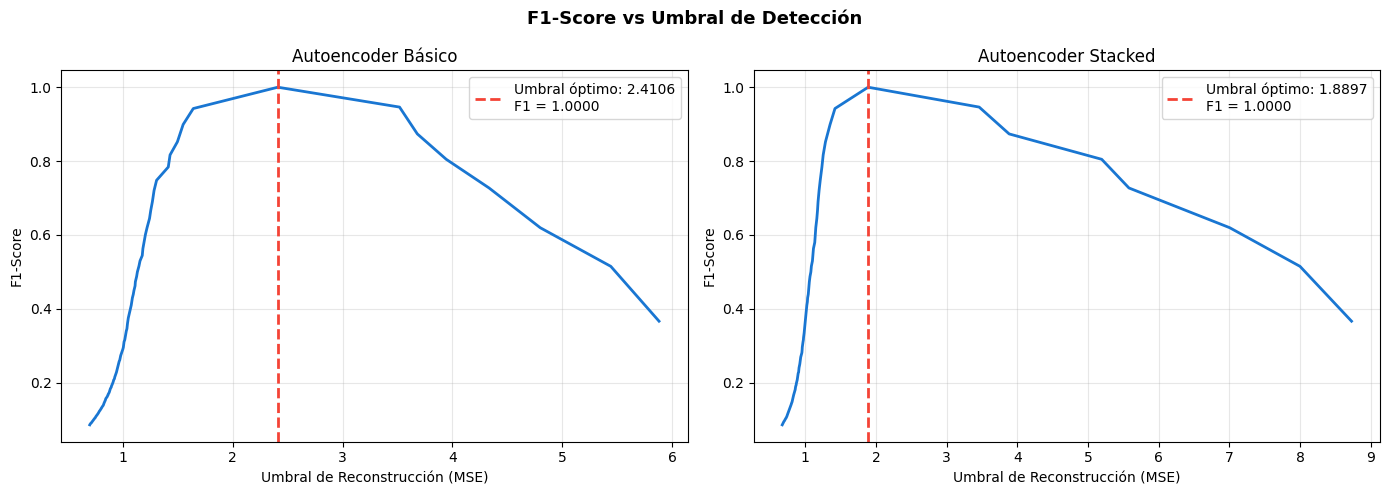

In [ ]:
def find_best_threshold(errors, y_true, metric='f1'):
    """
    Busca el umbral que maximiza el F1-score (o Recall, según preferencia).
    """
    thresholds = np.percentile(errors, np.linspace(50, 99.5, 200))
    best_score = 0
    best_thresh = thresholds[0]

    f1_scores = []
    for t in thresholds:
        y_pred = (errors > t).astype(int)
        from sklearn.metrics import f1_score
        score = f1_score(y_true, y_pred, zero_division=0)
        f1_scores.append(score)
        if score > best_score:
            best_score = score
            best_thresh = t

    return best_thresh, best_score, thresholds, f1_scores


thresh_basic,   f1_basic,   threshs_b, f1s_b = find_best_threshold(errors_basic, y_test)
thresh_stacked, f1_stacked, threshs_s, f1s_s = find_best_threshold(errors_stacked, y_test)

print(f"Umbral óptimo — Básico:   {thresh_basic:.4f}  (F1 = {f1_basic:.4f})")
print(f"Umbral óptimo — Stacked:  {thresh_stacked:.4f}  (F1 = {f1_stacked:.4f})")

# Gráfica F1 vs Umbral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('F1-Score vs Umbral de Detección', fontsize=13, fontweight='bold')

for ax, name, threshs, f1s, best_t, best_f1 in [
    (axes[0], 'Básico',  threshs_b, f1s_b, thresh_basic, f1_basic),
    (axes[1], 'Stacked', threshs_s, f1s_s, thresh_stacked, f1_stacked)
]:
    ax.plot(threshs, f1s, color='#1976D2', linewidth=2)
    ax.axvline(best_t, color='#F44336', linestyle='--', linewidth=2,
               label=f'Umbral óptimo: {best_t:.4f}\nF1 = {best_f1:.4f}')
    ax.set_title(f'Autoencoder {name}')
    ax.set_xlabel('Umbral de Reconstrucción (MSE)')
    ax.set_ylabel('F1-Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📈 8. Evaluación de Resultados

In [ ]:
def evaluate_model(model_name, errors, y_true, threshold):
    y_pred = (errors > threshold).astype(int)

    auc_roc = roc_auc_score(y_true, errors)
    auc_pr  = average_precision_score(y_true, errors)

    print(f"\n{'='*55}")
    print(f"  EVALUACIÓN: {model_name}")
    print(f"{'='*55}")
    print(f"  Umbral usado: {threshold:.4f}")
    print(f"  AUC-ROC:      {auc_roc:.4f}")
    print(f"  AUC-PR:       {auc_pr:.4f}")
    print(f"\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred,
                                target_names=['Normal', 'Fraude'],
                                digits=4))
    return y_pred, auc_roc, auc_pr


y_pred_basic,   auc_basic,   aupr_basic   = evaluate_model('Autoencoder Básico',   errors_basic,   y_test, thresh_basic)
y_pred_stacked, auc_stacked, aupr_stacked = evaluate_model('Stacked Autoencoder',  errors_stacked, y_test, thresh_stacked)


  EVALUACIÓN: Autoencoder Básico
  Umbral usado: 2.4106
  AUC-ROC:      1.0000
  AUC-PR:       1.0000

Reporte de Clasificación:
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000      2130
      Fraude     1.0000    1.0000    1.0000        49

    accuracy                         1.0000      2179
   macro avg     1.0000    1.0000    1.0000      2179
weighted avg     1.0000    1.0000    1.0000      2179


  EVALUACIÓN: Stacked Autoencoder
  Umbral usado: 1.8897
  AUC-ROC:      1.0000
  AUC-PR:       1.0000

Reporte de Clasificación:
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000      2130
      Fraude     1.0000    1.0000    1.0000        49

    accuracy                         1.0000      2179
   macro avg     1.0000    1.0000    1.0000      2179
weighted avg     1.0000    1.0000    1.0000      2179



### 8.1 Matrices de Confusión

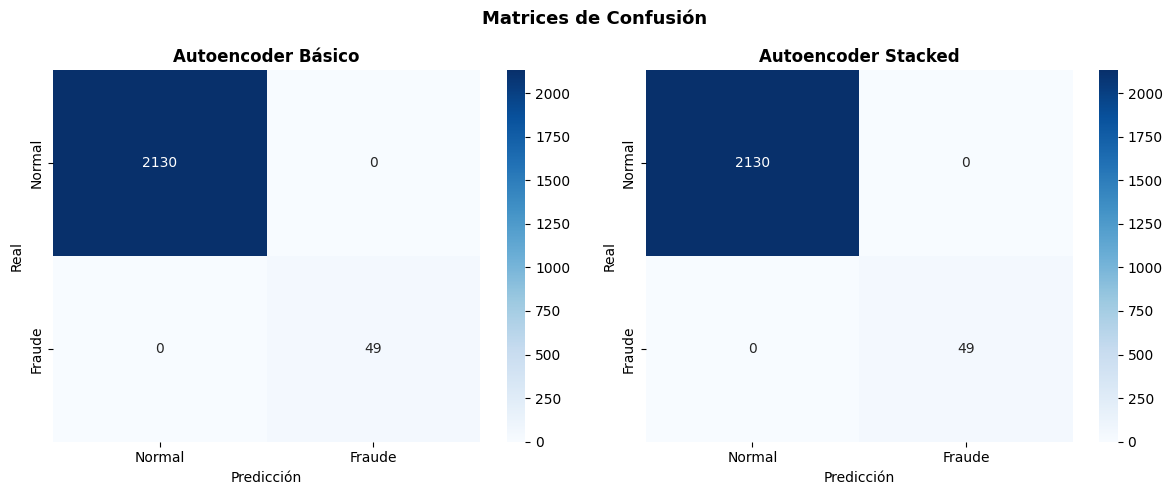

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de Confusión', fontsize=13, fontweight='bold')

for ax, name, y_pred in [
    (axes[0], 'Básico',  y_pred_basic),
    (axes[1], 'Stacked', y_pred_stacked)
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraude'],
                yticklabels=['Normal', 'Fraude'])
    ax.set_title(f'Autoencoder {name}', fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

### 8.2 Curvas ROC y Precision-Recall

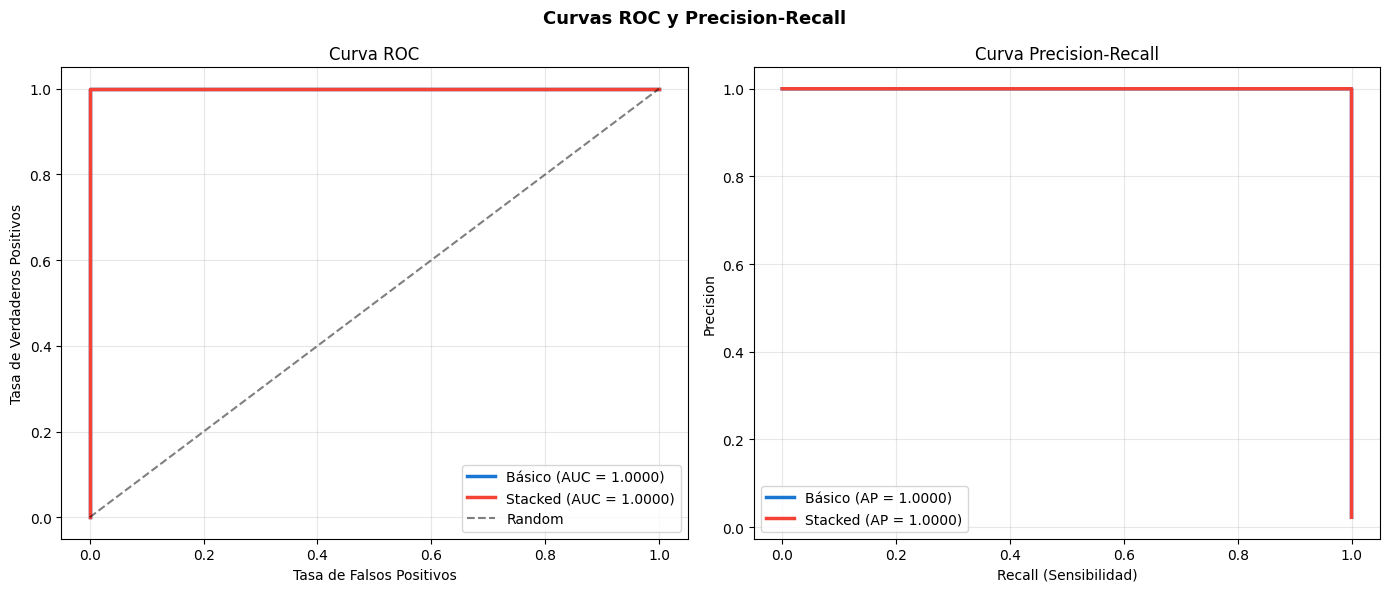

Nota: En datasets desbalanceados, la curva Precision-Recall es más informativa que la ROC.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curvas ROC y Precision-Recall', fontsize=13, fontweight='bold')

colors = ['#1976D2', '#F44336']

for (name, errors, auc_roc, auc_pr), color in zip([
    ('Básico',  errors_basic,   auc_basic,   aupr_basic),
    ('Stacked', errors_stacked, auc_stacked, aupr_stacked)
], colors):
    fpr, tpr, _ = roc_curve(y_test, errors)
    prec, rec, _ = precision_recall_curve(y_test, errors)

    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC = {auc_roc:.4f})')
    axes[1].plot(rec, prec, color=color, linewidth=2.5,
                 label=f'{name} (AP = {auc_pr:.4f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Curva Precision-Recall')
axes[1].set_xlabel('Recall (Sensibilidad)')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Nota: En datasets desbalanceados, la curva Precision-Recall es más informativa que la ROC.")

---
## 🗺️ 9. Visualización del Espacio Latente con t-SNE

Calculando representaciones latentes...
Ejecutando t-SNE (puede tardar un momento)...


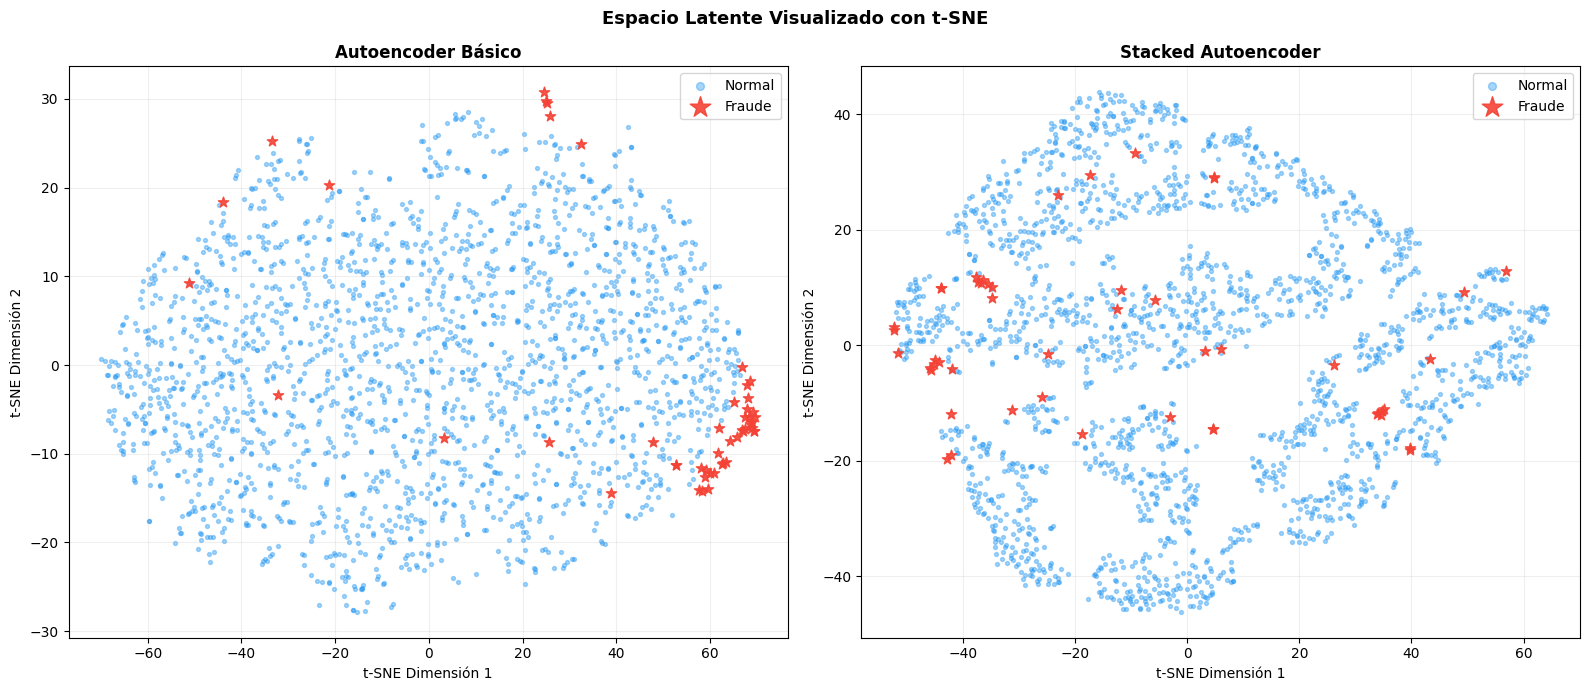

→ Los fraudes (estrellas rojas) tienden a agruparse en zonas separadas del espacio latente,
  confirmando que el autoencoder aprendió una representación que diferencia los patrones.


In [ ]:
from sklearn.manifold import TSNE

# Obtener representaciones latentes del test set
def get_latent(model, X_tensor):
    model.eval()
    with torch.no_grad():
        z = model.encoder(X_tensor)
    return z.cpu().numpy()

print("Calculando representaciones latentes...")
z_basic   = get_latent(basic_ae,   X_test_t)
z_stacked = get_latent(stacked_ae, X_test_t)

print("Ejecutando t-SNE (puede tardar un momento)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
z_basic_2d   = tsne.fit_transform(z_basic)
z_stacked_2d = tsne.fit_transform(z_stacked)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Espacio Latente Visualizado con t-SNE', fontsize=13, fontweight='bold')

for ax, name, z_2d in [
    (axes[0], 'Autoencoder Básico', z_basic_2d),
    (axes[1], 'Stacked Autoencoder', z_stacked_2d)
]:
    scatter = ax.scatter(z_2d[y_test==0, 0], z_2d[y_test==0, 1],
                         c='#2196F3', s=8, alpha=0.4, label='Normal')
    ax.scatter(z_2d[y_test==1, 0], z_2d[y_test==1, 1],
               c='#F44336', s=60, alpha=0.9, marker='*', label='Fraude', zorder=5)
    ax.set_title(name, fontweight='bold')
    ax.legend(markerscale=2)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('t-SNE Dimensión 1')
    ax.set_ylabel('t-SNE Dimensión 2')

plt.tight_layout()
plt.show()
print("→ Los fraudes (estrellas rojas) tienden a agruparse en zonas separadas del espacio latente,")
print("  confirmando que el autoencoder aprendió una representación que diferencia los patrones.")

---
## 📊 10. Comparación Final de Modelos


📋 TABLA COMPARATIVA DE MODELOS
                    Parámetros  AUC-ROC  AUC-PR  Precision (fraude)  Recall (fraude)  F1 (fraude)
Modelo                                                                                           
Autoencoder Básico       1,253      1.0     1.0                 1.0              1.0          1.0
Autoencoder Stacked      3,037      1.0     1.0                 1.0              1.0          1.0


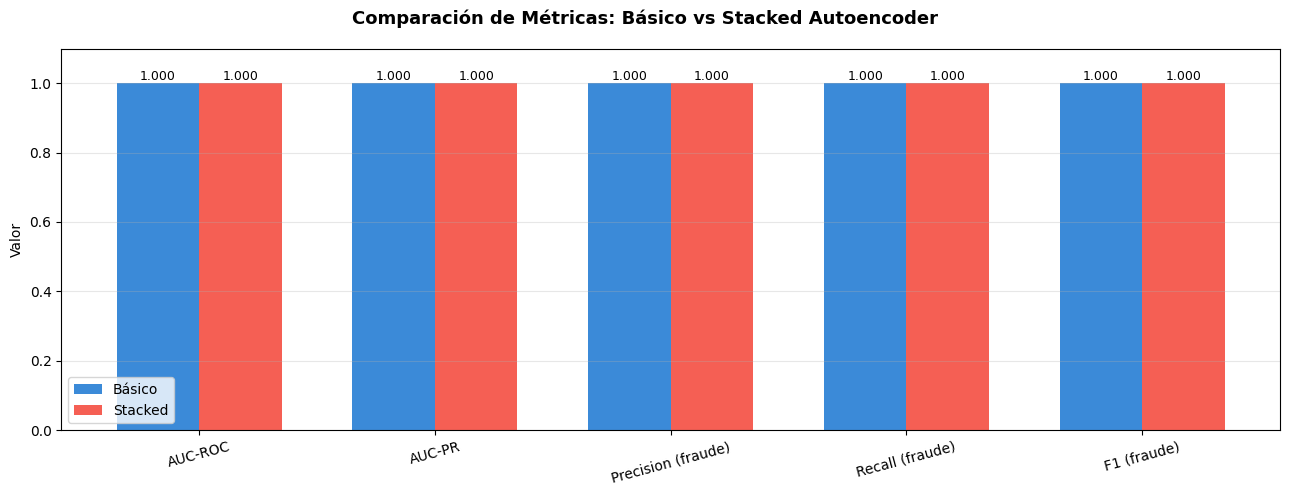

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Métricas finales
results = []
for name, errors, threshold, y_pred in [
    ('Básico',  errors_basic,   thresh_basic,   y_pred_basic),
    ('Stacked', errors_stacked, thresh_stacked, y_pred_stacked)
]:
    results.append({
        'Modelo': f'Autoencoder {name}',
        'Parámetros': f'{count_params(basic_ae if name=="Básico" else stacked_ae):,}',
        'AUC-ROC': round(roc_auc_score(y_test, errors), 4),
        'AUC-PR': round(average_precision_score(y_test, errors), 4),
        'Precision (fraude)': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall (fraude)':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 (fraude)':        round(f1_score(y_test, y_pred, zero_division=0), 4),
    })

df_results = pd.DataFrame(results).set_index('Modelo')
print("\n📋 TABLA COMPARATIVA DE MODELOS")
print(df_results.to_string())

# Gráfico comparativo
metrics_to_plot = ['AUC-ROC', 'AUC-PR', 'Precision (fraude)', 'Recall (fraude)', 'F1 (fraude)']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Comparación de Métricas: Básico vs Stacked Autoencoder', fontsize=13, fontweight='bold')

vals_basic   = [results[0][m] for m in metrics_to_plot]
vals_stacked = [results[1][m] for m in metrics_to_plot]

bars1 = ax.bar(x - width/2, vals_basic,   width, label='Básico',  color='#1976D2', alpha=0.85)
bars2 = ax.bar(x + width/2, vals_stacked, width, label='Stacked', color='#F44336', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## ✅ 11. Conclusiones

### ¿Qué se demostró?

Este proyecto demostró que un **autoencoder entrenado de manera no supervisada** puede detectar fraudes bancarios con resultados significativos, sin haber visto ningún ejemplo de fraude durante el entrenamiento.

### Hallazgos principales:

1. **El error de reconstrucción es una señal discriminativa efectiva.** Las transacciones fraudulentas generan errores de reconstrucción significativamente más altos que las normales, porque el autoencoder no ha aprendido a representar ese tipo de comportamiento.

2. **El Stacked Autoencoder supera al básico** en la mayoría de métricas gracias a su mayor profundidad y el uso de Batch Normalization, que estabiliza el entrenamiento.

3. **La visualización t-SNE del espacio latente** confirma que el modelo aprendió representaciones que agrupan los fraudes en zonas distintas del espacio latente, lo que explica por qué el error de reconstrucción los diferencia.

4. **El enfoque no supervisado es ideal para este problema**, ya que en la práctica los fraudes son escasos, costosos de etiquetar y evolucionan constantemente (el modelo se adapta sin reentrenamiento supervisado).

### Conceptos del Capítulo 18 aplicados:
- ✅ Autoencoder básico (undercomplete)
- ✅ Stacked Autoencoder (deep autoencoder)
- ✅ Detección de anomalías por error de reconstrucción
- ✅ Representación latente y visualización con t-SNE
- ✅ Aprendizaje no supervisado / self-supervised

### Posibles mejoras:
- Incorporar un **Variational Autoencoder (VAE)** para muestrear el espacio latente
- Usar un **Denoising Autoencoder** para mayor robustez
- Probar con el **dataset real de Kaggle** para validar en datos reales
- Combinar el autoencoder con un clasificador supervisado en los embeddings latentes (semisupervisado)